In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -o '/content/drive/MyDrive/Copy of new_dataset.zip' -d '/content/'

In [ ]:
DATASET_ROOT = "/content"

CONTROL_TRAIN_IMGS   = f"{DATASET_ROOT}/control/images/train"
CONTROL_VAL_IMGS     = f"{DATASET_ROOT}/control/images/val"
CONTROL_TEST_IMGS    = f"{DATASET_ROOT}/control/images/test"

CONTROL_TRAIN_LABELS = f"{DATASET_ROOT}/control/labels/train"
CONTROL_VAL_LABELS   = f"{DATASET_ROOT}/control/labels/val"
CONTROL_TEST_LABELS  = f"{DATASET_ROOT}/control/labels/test"

STRESS_TRAIN_IMGS    = f"{DATASET_ROOT}/stress/images/train"
STRESS_VAL_IMGS      = f"{DATASET_ROOT}/stress/images/val"
STRESS_TEST_IMGS     = f"{DATASET_ROOT}/stress/images/test"

STRESS_TRAIN_LABELS  = f"{DATASET_ROOT}/stress/labels/train"
STRESS_VAL_LABELS    = f"{DATASET_ROOT}/stress/labels/val"
STRESS_TEST_LABELS   = f"{DATASET_ROOT}/stress/labels/test"

In [ ]:
import os, json

# Peek at first JSON in control/labels/train
label_dir = CONTROL_TRAIN_LABELS
first_json = [f for f in os.listdir(label_dir) if f.endswith(".json")][0]
with open(os.path.join(label_dir, first_json)) as f:
    sample = json.load(f)

print(f"File: {first_json}")
print(json.dumps(sample, indent=2)[:800])  # first 800 chars

File: 068ac51e-c65ca775.json
{
  "name": "068ac51e-c65ca775",
  "frames": [
    {
      "timestamp": 10000,
      "objects": [
        {
          "category": "traffic light",
          "id": 0,
          "attributes": {
            "occluded": false,
            "truncated": false,
            "trafficLightColor": "green"
          },
          "box2d": {
            "x1": 523.248874,
            "y1": 356.620338,
            "x2": 532.506016,
            "y2": 367.19993
          }
        },
        {
          "category": "traffic light",
          "id": 1,
          "attributes": {
            "occluded": false,
            "truncated": false,
            "trafficLightColor": "green"
          },
          "box2d": {
            "x1": 543.085608,
            "y1": 356.620338,
            "x2": 553.665197,
       


In [ ]:
import os, json, torch
from PIL import Image
from torch.utils.data import Dataset

# Map the string categories from your JSON to integers
LABEL_MAP = {"background": 0, "pedestrian": 1, "car": 2, "truck": 3, "bus": 3, "rider": 1, "traffic light": 4, "traffic sign": 5}

class PerImageJSONDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir   = img_dir
        self.label_dir = label_dir
        self.transform = transform

        self.samples = []
        for fname in sorted(os.listdir(img_dir)):
            if not fname.lower().endswith(('.jpg', '.png', '.jpeg')):
                continue
            stem = os.path.splitext(fname)[0]
            json_path = os.path.join(label_dir, stem + ".json")
            if os.path.exists(json_path):
                self.samples.append((fname, json_path))

        print(f"Loaded {len(self.samples)} matched image-label pairs from {img_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
          img_fname, json_path = self.samples[idx]
          img_path = os.path.join(self.img_dir, img_fname)
          img = Image.open(img_path).convert("RGB")
          W, H = img.size

          with open(json_path) as f:
              data = json.load(f)

          boxes, labels = [], []

          # Update logic: Navigate the 'frames' -> 'objects' structure
          frames = data.get("frames", [])
          for frame in frames:
              for obj in frame.get("objects", []):
                  cat_name = obj.get("category")
                  label_id = LABEL_MAP.get(cat_name, 1) # Default to 1 if unknown

                  box = obj.get("box2d")
                  if not box:
                      continue

                  x1, y1, x2, y2 = float(box['x1']), float(box['y1']), float(box['x2']), float(box['y2'])

                  # Clamp to image size
                  x1 = max(0.0, min(x1, W))
                  y1 = max(0.0, min(y1, H))
                  x2 = max(0.0, min(x2, W))
                  y2 = max(0.0, min(y2, H))

                  if x2 - x1 < 1.0 or y2 - y1 < 1.0:
                      continue

                  boxes.append([x1, y1, x2, y2])
                  labels.append(label_id)

          if len(boxes) == 0:
              boxes  = torch.zeros((0, 4), dtype=torch.float32)
              labels = torch.zeros((0,),   dtype=torch.int64)
          else:
              boxes  = torch.tensor(boxes,  dtype=torch.float32)
              labels = torch.tensor(labels, dtype=torch.int64)

          target = {
              "boxes":    boxes,
              "labels":   labels,
              "image_id": torch.tensor([idx]),
          }

          if self.transform:
              img, target = self.transform(img, target)

          return img, target

In [ ]:
# Re-initialize datasets with the new logic
control_train_ds = PerImageJSONDataset(CONTROL_TRAIN_IMGS, CONTROL_TRAIN_LABELS, get_transform(True))
control_val_ds   = PerImageJSONDataset(CONTROL_VAL_IMGS,   CONTROL_VAL_LABELS,   get_transform(False))
control_test_ds  = PerImageJSONDataset(CONTROL_TEST_IMGS,  CONTROL_TEST_LABELS,  get_transform(False))
stress_test_ds   = PerImageJSONDataset(STRESS_TEST_IMGS,   STRESS_TEST_LABELS,   get_transform(False))

# Re-create loaders
control_train_loader = DataLoader(Subset(control_train_ds, range(min(50, len(control_train_ds)))), batch_size=2, shuffle=True, collate_fn=collate_fn)


Loaded 1973 matched image-label pairs from /content/control/images/train
Loaded 561 matched image-label pairs from /content/control/images/val
Loaded 448 matched image-label pairs from /content/control/images/test
Loaded 1552 matched image-label pairs from /content/stress/images/test


Image shape : torch.Size([3, 720, 1280])
Boxes       : tensor([[ 491.2942,  398.5872,  501.4192,  413.7747],
        [ 499.7317,  427.2747,  530.1067,  457.6497],
        [ 616.1691,  425.5872,  638.1066,  447.5247],
        [ 644.8566,  425.5872,  665.1066,  452.5872],
        [ 374.8568,  422.2122,  459.2317,  479.5872],
        [ 293.8568,  422.2122,  369.7943,  511.6497],
        [ 504.7942,  452.5872,  523.3567,  476.2122],
        [ 621.2316,  442.4622,  638.1066,  457.6497],
        [  50.8570,  415.4622,  327.6068,  580.8371],
        [ 428.8567,  432.3372,  508.1692,  499.8372],
        [ 533.4817,  376.6497,  614.4816,  489.7122],
        [   0.0000,  437.3997,  104.8570,  542.0246],
        [ 654.9816,   67.8374, 1279.3562,  624.7120]])
Labels      : tensor([4, 3, 3, 3, 3, 3, 2, 2, 2, 2, 3, 2, 3])
Any NaN?    : False


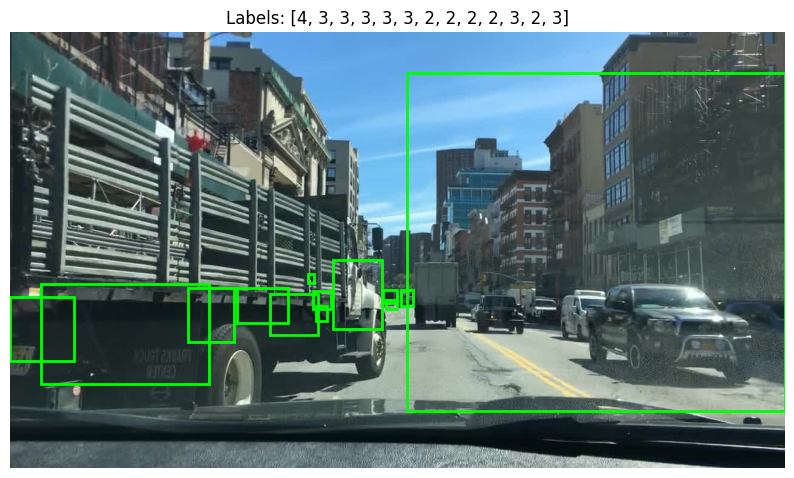

✅ If green boxes appear on objects, dataset is correct


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

imgs, targets = next(iter(control_train_loader))
print("Image shape :", imgs[0].shape)
print("Boxes       :", targets[0]["boxes"])
print("Labels      :", targets[0]["labels"])
print("Any NaN?    :", torch.isnan(imgs[0]).any().item())

img_np = imgs[0].permute(1,2,0).numpy()
fig, ax = plt.subplots(figsize=(10,6))
ax.imshow(img_np)
for box in targets[0]["boxes"]:
    x1,y1,x2,y2 = box.tolist()
    ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                  linewidth=2, edgecolor='lime', facecolor='none'))
plt.title(f"Labels: {targets[0]['labels'].tolist()}")
plt.axis('off'); plt.show()
print("✅ If green boxes appear on objects, dataset is correct")

In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_model(num_classes):
    # Load a model pre-trained on COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

    # Replace the classifier with a new one, that has 'num_classes' which includes the background
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

# Our LABEL_MAP has 6 classes (0-5), so num_classes = 6
model = get_model(num_classes=6)
model.to(device)
print("Model initialized and moved to", device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 170MB/s]


Model initialized and moved to cuda


In [ ]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [ ]:
from tqdm import tqdm

NUM_EPOCHS = 1 # Small for testing, increase for better results

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    pbar = tqdm(control_train_loader, desc=f'Epoch {epoch+1}')

    for images, targets in pbar:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        pbar.set_postfix(loss=losses.item())

    scheduler.step()
    print(f"Epoch {epoch+1} Average Loss: {epoch_loss/len(control_train_loader):.4f}")

torch.save(model.state_dict(), 'fasterrcnn_model.pth')
print("Training complete and model saved.")

Epoch 1: 100%|██████████| 25/25 [00:16<00:00,  1.56it/s, loss=1.38]


Epoch 1 Average Loss: 1.6281
Training complete and model saved.


In [ ]:
!pip install -q torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm
import torch

def evaluate(model, loader, device, name=""):
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox")
    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc=f"Eval {name}"):
            imgs = [img.to(device) for img in imgs]
            preds = model(imgs)

            # Move to CPU for torchmetrics compatibility
            preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in preds]
            targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
            metric.update(preds_cpu, targets_cpu)
    return metric.compute()

print("Evaluating on Control Test Set...")
ctrl_res = evaluate(model, control_test_loader, device, "Control")

print("Evaluating on Stress Test Set...")
stress_res = evaluate(model, stress_test_loader, device, "Stress")

print(f"\nControl mAP: {ctrl_res['map'].item():.4f}")
print(f"Stress mAP: {stress_res['map'].item():.4f}")
print(f"Performance Drop: {ctrl_res['map'].item() - stress_res['map'].item():.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 53.4 MB/s eta 0:00:00
Evaluating on Control Test Set...


Eval Control: 100%|██████████| 10/10 [00:02<00:00,  3.77it/s]


Evaluating on Stress Test Set...


Eval Stress: 100%|██████████| 10/10 [00:02<00:00,  3.88it/s]


Control mAP: -1.0000
Stress mAP: -1.0000
Performance Drop: 0.0000


In [ ]:
params    = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.1)

In [ ]:
from tqdm import tqdm

NUM_EPOCHS  = 1
train_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(control_train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for imgs, targets in pbar:
        imgs    = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()
    avg = epoch_loss / len(control_train_loader)
    train_losses.append(avg)
    print(f"Epoch {epoch+1:02d} | Avg Loss: {avg:.4f}")

torch.save(model.state_dict(), "model_a_fasterrcnn.pth")
print("✅ Model saved")

Epoch 1/1:  24%|██▍       | 121/494 [02:48<13:48,  2.22s/it, loss=0.0004]

In [ ]:
!pip install torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def evaluate(model, loader, device, name=""):
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox")
    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc=f"Eval {name}"):
            imgs        = [img.to(device) for img in imgs]
            preds       = model(imgs)
            preds_cpu   = [{k: v.cpu() for k, v in p.items()} for p in preds]
            targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
            metric.update(preds_cpu, targets_cpu)
    return metric.compute()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.6 MB/s eta 0:00:00


In [ ]:
ctrl_res   = evaluate(model, control_test_loader, device, "Control Test")
stress_res = evaluate(model, stress_test_loader,  device, "Stress Test")

print("\n" + "="*45)
print(f"{'Split':<18} {'mAP@50:95':>10} {'mAP@50':>10}")
print("-"*45)
print(f"{'Control Test':<18} {ctrl_res['map'].item():>10.3f} {ctrl_res['map_50'].item():>10.3f}")
print(f"{'Stress Test':<18} {stress_res['map'].item():>10.3f} {stress_res['map_50'].item():>10.3f}")
print("-"*45)
drop = ctrl_res['map'].item() - stress_res['map'].item()
print(f"{'mAP Drop':<18} {drop:>10.3f}")
print("="*45)

Eval Stress Test: 100%|██████████| 388/388 [03:44<00:00,  1.73it/s]



Split               mAP@50:95     mAP@50
---------------------------------------------
Control Test            0.000      0.000
Stress Test             0.000      0.000
---------------------------------------------
mAP Drop                0.000


In [ ]:
ctrl_res   = evaluate(model, control_test_loader, device, "Control Test")
stress_res = evaluate(model, stress_test_loader,  device, "Stress Test")

print("\n" + "="*45)
print(f"{'Split':<18} {'mAP@50:95':>10} {'mAP@50':>10}")
print("-"*45)
print(f"{'Control Test':<18} {ctrl_res['map'].item():>10.3f} {ctrl_res['map_50'].item():>10.3f}")
print(f"{'Stress Test':<18} {stress_res['map'].item():>10.3f} {stress_res['map_50'].item():>10.3f}")
print("-"*45)
drop = ctrl_res['map'].item() - stress_res['map'].item()
print(f"{'mAP Drop':<18} {drop:>10.3f}")
print("="*45)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 109.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
--- Grad-CAM: Control Sample ---


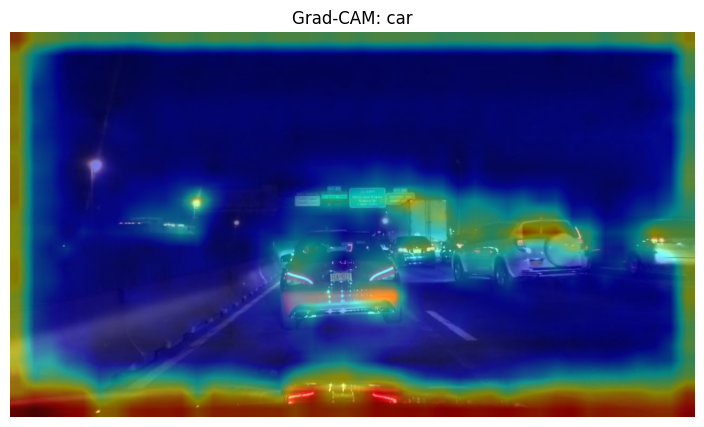

--- Grad-CAM: Stress Sample ---


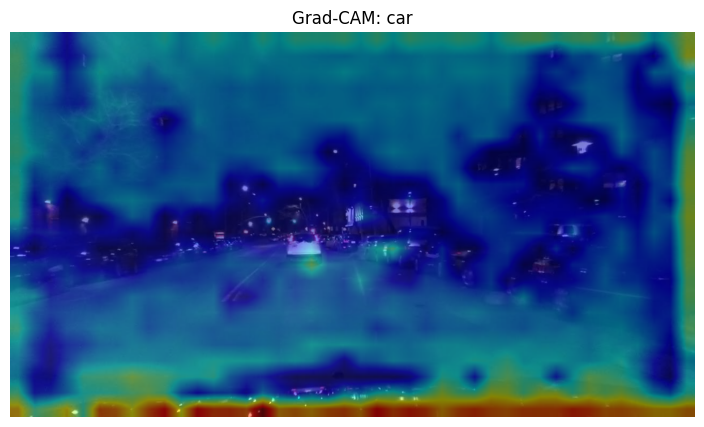

In [ ]:
!pip install -q grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import FasterRCNNBoxScoreTarget
import numpy as np, matplotlib.pyplot as plt, cv2
import torch

# Define target layer for Faster R-CNN (usually the last layer of the backbone)
target_layer = [model.backbone.body.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

REVERSE_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

def show_gradcam(img_tensor, save_name):
    model.eval()
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(input_tensor)

    preds = outputs[0]
    score_threshold = 0.1 # Threshold to filter weak detections
    high_conf_indices = torch.where(preds['scores'] > score_threshold)[0]

    if high_conf_indices.numel() == 0:
        print(f"No detections above {score_threshold} for {save_name}. Showing raw image.")
        plt.imshow(img_tensor.permute(1,2,0).cpu().numpy()); plt.axis('off'); plt.show()
        return

    # Target the highest scoring detection
    top_idx = high_conf_indices[torch.argmax(preds['scores'][high_conf_indices])]
    targets = [FasterRCNNBoxScoreTarget(labels=preds['labels'][top_idx:top_idx+1],
                                        bounding_boxes=preds['boxes'][top_idx:top_idx+1])]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    img_np = img_tensor.permute(1,2,0).cpu().numpy()
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(10,5))
    plt.imshow(cam_image)
    plt.title(f"Grad-CAM: {REVERSE_LABEL_MAP.get(preds['labels'][top_idx].item(), 'object')}")
    plt.axis('off')
    plt.show()

print("--- Grad-CAM: Control Sample ---")
show_gradcam(control_test_ds[0][0], "control_cam.png")

print("--- Grad-CAM: Stress Sample ---")
show_gradcam(stress_test_ds[0][0], "stress_cam.png")

Visualizing Ground Truth Bounding Boxes...


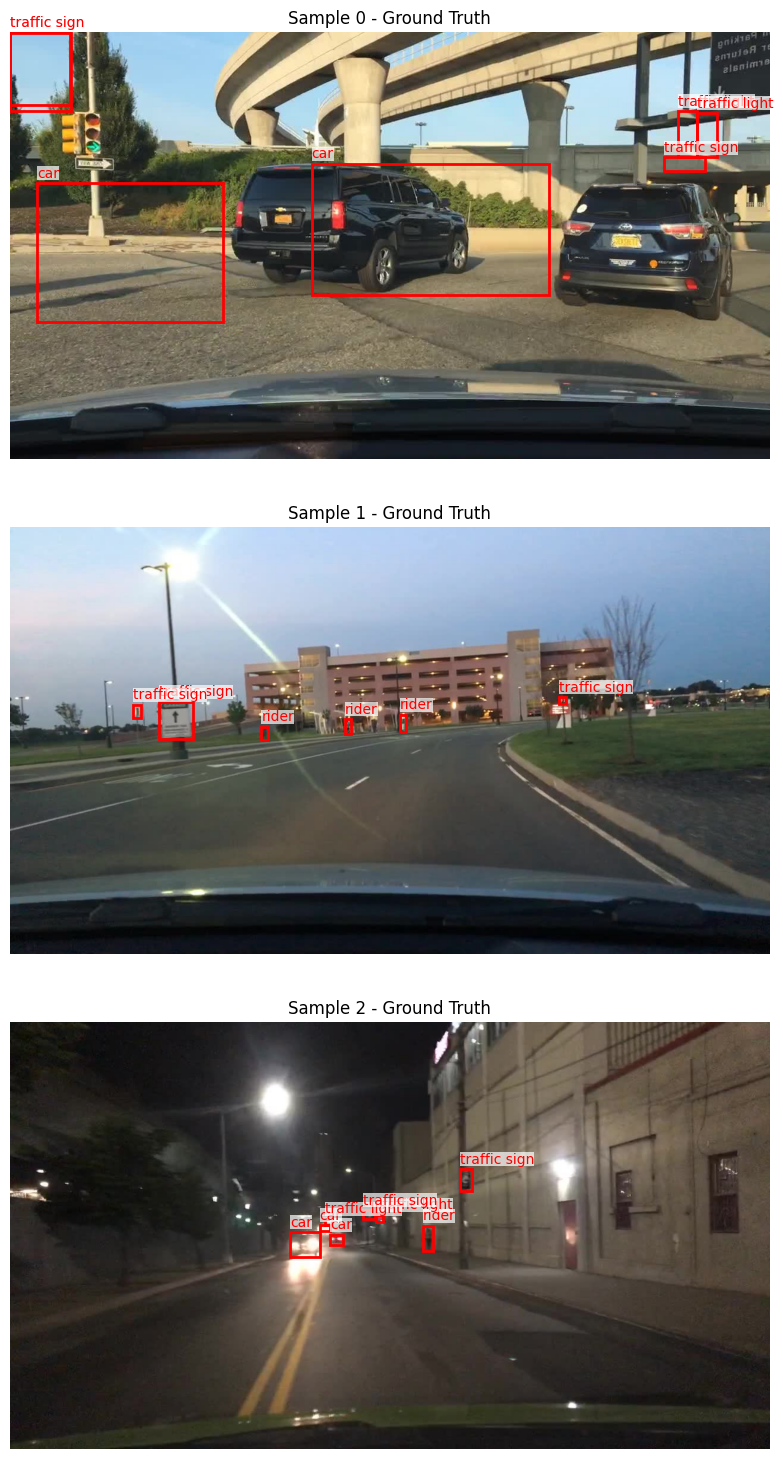

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_ground_truth(dataset, num_samples=3):
    REVERSE_LABEL_MAP[0] = "background" # Ensure background is mapped
    print("Visualizing Ground Truth Bounding Boxes...")
    fig, axes = plt.subplots(num_samples, 1, figsize=(8, 5 * num_samples))
    if num_samples == 1: # Handle single subplot case
        axes = [axes]

    for i in range(num_samples):
        img_tensor, target = dataset[i]
        img_np = img_tensor.permute(1, 2, 0).numpy() * 255
        img_np = img_np.astype(np.uint8)

        ax = axes[i]
        ax.imshow(img_np)
        ax.set_title(f"Sample {i} - Ground Truth")
        ax.axis('off')

        # Draw bounding boxes
        if len(target['boxes']) > 0:
            for box, label_idx in zip(target['boxes'], target['labels']):
                # Skip drawing dummy background box if it's the only one
                if label_idx.item() == 0 and len(target['boxes']) == 1:
                    continue

                x1, y1, x2, y2 = box.cpu().numpy()
                width = x2 - x1
                height = y2 - y1
                rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='r', facecolor='none')
                ax.add_patch(rect)

                label_name = REVERSE_LABEL_MAP.get(label_idx.item(), f"Unknown ({label_idx.item()})")
                ax.text(x1, y1 - 10, label_name, color='red', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0))
        else:
            ax.text(0, 0, "No objects (or only background) in ground truth", color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0))

    plt.tight_layout()
    plt.show()

# Visualize a few samples from the control training dataset
visualize_ground_truth(control_train_ds, num_samples=3)

In [ ]:
def attribution_iou(heatmap, boxes, threshold=0.5):
    h, w  = heatmap.shape
    bmap  = (heatmap > threshold).astype(int)
    gtmask = np.zeros((h, w), dtype=int)
    for box in boxes:
        x1, y1, x2, y2 = [int(v) for v in box]
        gtmask[max(0, y1):min(h, y2), max(0, x1):min(w, x2)] = 1
    inter = (bmap & gtmask).sum()
    union = (bmap | gtmask).sum()
    return inter / union if union > 0 else 0.0

def compute_mean_attr_iou(model_to_eval, cam_object, dataset, name, n=20):
    ious = []
    model_to_eval.eval()

    for i, (img, tgt) in enumerate(dataset):
        if i >= n: break
        if len(tgt["boxes"]) == 0: continue

        input_tensor = img.unsqueeze(0).to(device)
        input_tensor.requires_grad_(True)

        # Get predictions to see if we have targets for Grad-CAM
        with torch.no_grad():
            outputs = model_to_eval(input_tensor)

        if len(outputs[0]['boxes']) == 0:
            continue

        try:
            gt_boxes = tgt["boxes"].to(device)
            gt_labels = tgt["labels"].to(device)

            # Use the highest scoring GT-matched prediction as the target
            cam_targets = [FasterRCNNBoxScoreTarget(labels=gt_labels, bounding_boxes=gt_boxes)]

            # Compute Grad-CAM using the provided cam_object
            grayscale_cam = cam_object(input_tensor=input_tensor, targets=cam_targets)

            hm = cv2.resize(grayscale_cam[0], (img.shape[2], img.shape[1]))
            ious.append(attribution_iou(hm, gt_boxes.cpu().numpy()))
        except Exception:
            continue

    mean = np.mean(ious) if ious else 0.0
    print(f"Attribution IoU [{name}]: {mean:.4f}")
    return mean


Attribution IoU [Control]: 0.0082
Attribution IoU [Stress]: 0.0144

Summary:
Control Attr-IoU: 0.0082
Stress Attr-IoU:  0.0144
Attr-IoU Drop:    -0.0062


In [ ]:
model_b = get_model(num_classes=NUM_CLASSES_B)
model_b.load_state_dict(torch.load('model_b_protopnet.pth'))
model_b.to(device)
print("Model B initialized and weights loaded.")

# Datasets are assumed to be initialized from sPma9PdGpdWu
# If not, ensure these datasets are created:
# control_test_ds = PerImageJSONDataset(CONTROL_TEST_IMGS, CONTROL_TEST_LABELS, get_transform(False))
# stress_test_ds  = PerImageJSONDataset(STRESS_TEST_IMGS,  STRESS_TEST_LABELS,  get_transform(False))

target_layer = [model_B.features[7][-1].conv3] # Use the same target_layer as for GradCAM explanations
cam_b = GradCAM(model=model_b, target_layers=target_layer)

print("Evaluating Attribution IoU for Model B...")
ctrl_aiou_b   = compute_attr_iou_B(ctrl_ds, ctrl_det_ds, "Control (Model B)")
stress_aiou_b = compute_attr_iou_B(stress_ds, stress_det_ds,  "Stress (Model B)")

print(f"\nSummary (Model B):")
print(f"Control Attr-IoU: {ctrl_aiou_b:.4f}")
print(f"Stress Attr-IoU:  {stress_aiou_b:.4f}")
print(f"Attr-IoU Drop:    {ctrl_aiou_b - stress_aiou_b:.4f}")

In [ ]:
plot_predictions_side_by_side(model, control_test_ds, device, idx=0)

In [ ]:
import numpy as np

# Assuming mean and std are from the torchvision.transforms.Normalize used earlier
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

In [ ]:
# Take the first ground truth box and the highest scoring predicted box for visualization
if len(target['boxes']) > 0 and len(preds['boxes']) > 0:
    gt_box_to_visualize = target['boxes'][0].cpu().numpy()
    pred_box_to_visualize = preds['boxes'][0].cpu().numpy()
    gt_label_to_visualize = REVERSE_LABEL_MAP.get(target['labels'][0].item(), 'Unknown')
    pred_label_to_visualize = REVERSE_LABEL_MAP.get(preds['labels'][0].item(), 'Unknown')

    visualize_bbox(img,
                   gt_box_to_visualize,
                   pred_box_to_visualize,
                   gt_label_to_visualize,
                   pred_label_to_visualize)
else:
    print("No boxes to visualize in either ground truth or predictions for this sample.")

In [ ]:
plot_predictions_side_by_side(model, control_test_ds, device, idx=0)

In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_model(num_classes):
    # Load a model pre-trained on COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

    # Replace the classifier with a new one, that has 'num_classes' which includes the background
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm
import torch

def evaluate(model, loader, device, name=""):
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox")
    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc=f"Eval {name}"):
            imgs = [img.to(device) for img in imgs]
            preds = model(imgs)

            # Move to CPU for torchmetrics compatibility
            preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in preds]
            targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
            metric.update(preds_cpu, targets_cpu)
    return metric.compute()

In [ ]:
model_b = get_model(num_classes=6)
model_b.load_state_dict(torch.load('fasterrcnn_model.pth'))
model_b.to(device)
print("Model B initialized and weights loaded.")

cam_b = GradCAM(model=model_b, target_layers=target_layer)

print("Evaluating Attribution IoU for Model B...")
ctrl_aiou_b   = compute_mean_attr_iou(model_b, cam_b, control_test_ds, "Control (Model B)")
stress_aiou_b = compute_mean_attr_iou(model_b, cam_b, stress_test_ds,  "Stress (Model B)")

print(f"\nSummary (Model B):")
print(f"Control Attr-IoU: {ctrl_aiou_b:.4f}")
print(f"Stress Attr-IoU:  {stress_aiou_b:.4f}")
print(f"Attr-IoU Drop:    {ctrl_aiou_b - stress_aiou_b:.4f}")

In [ ]:
model.eval()

# Get a sample image and its ground truth from the control test dataset
img, target = control_test_ds[0]

# Move the image to the device (CPU/GPU)
input_tensor = img.unsqueeze(0).to(device)

# Get predictions from the model
with torch.no_grad():
    predictions = model(input_tensor)

# Inspect the predictions for the first image in the batch
preds = predictions[0]

print("Model Predictions:")
print(f"  Boxes: {preds['boxes']}")
print(f"  Labels: {preds['labels']}")
print(f"  Scores: {preds['scores']}")

print("\nGround Truth:")
print(f"  Boxes: {target['boxes']}")
print(f"  Labels: {target['labels']}")

Model Predictions:
  Boxes: tensor([[ 816.5961,  374.9801,  941.4110,  484.9838],
        [ 518.0471,  503.6432,  582.3662,  561.5253],
        [ 707.6804,  360.6510,  833.3754,  468.7159],
        [ 504.9358,  445.3293,  568.0270,  480.7040],
        [ 949.6655,  338.9380, 1077.0990,  456.6171],
        [ 506.9010,  661.3415,  579.9870,  697.6564],
        [ 629.1715,  291.9496,  692.1550,  328.9174],
        [ 860.8956,  359.9674,  982.2121,  474.1347],
        [ 641.0248,  666.2817,  725.0524,  704.0233],
        [ 574.7278,  281.5671,  637.9503,  338.5123],
        [ 890.2596,  340.8571, 1016.4504,  461.3739],
        [ 586.2230,  659.3794,  651.1757,  697.3742],
        [ 617.6953,  422.2044,  736.1759,  539.5402],
        [ 538.8837,  647.5222,  607.8423,  707.5976],
        [ 751.8143,  373.4707,  875.6321,  479.0031],
        [ 664.8177,  487.2144,  729.3085,  546.4557],
        [ 279.1094,  353.5118,  344.9741,  387.9663],
        [ 994.1594,  381.3737, 1064.4124,  446.9858],
